#**Assignment 2: Processing Datasets in Python**

**Class Schedule:** V4-V6 LMMJV

Andrea Sofía Cantú Trejo 2120574

Pablo Andrés Villarreal Cárdenas 2043233

Julia Aracely Muñoz González 2094919

Oscar Daniel Cruz Cruz 2094531

### **Part 1. Data Loading and Initial Exploration**
In this section, we load the medical dataset using the Pandas library. We preview the first rows of the dataframe using df.head() to get a first look at the structure of the data and understand the nature of the information we will be working with.

In [29]:
# Loading Pandas library and the dataset given by the instructor.
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('diabetes.csv')
# Displaying the first few rows of the dataset
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


### **Detection of Anomalies and Inconsistencies**
While analyzing the descriptive statistics, a critical anomaly was identified: key biological variables such as glucose, blood pressure, skin thickness, insulin, and BMI present minimum values equal to zero. Since the absolute absence of these indicators is incompatible with life, we determine that these zeros represent missing data or recording errors that must be addressed.

In [30]:
# Identifying any null or incosistent values in columns
print(df.eq(0).any())

Pregnancies                  True
Glucose                      True
BloodPressure                True
SkinThickness                True
Insulin                      True
BMI                          True
DiabetesPedigreeFunction    False
Age                         False
Outcome                      True
dtype: bool


In [31]:
# Generating descriptive statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **Part 2: Data Cleaning and Normalization**

To avoid losing valuable information by deleting entire rows, we perform a data curation process. We replace the inconsistent zero values with the median of each respective column. The median is used instead of the mean because it is a more robust metric against outliers, ensuring a clinically and structurally coherent treatment of the dataset.

Once the data is clean, we apply a normalization process using the Min-Max scaling technique. This method transforms the numerical values of the different variables so that they fit strictly within a range of 0 to 1. This step is essential to ensure that features with larger magnitudes do not skew the analysis or disproportionately affect the performance of future machine learning models.

In [32]:
# Replacing the values equal to zero for the median of each column
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols:
    df[col] = df[col].replace(0,df[col].median())
# Generating a copy of the dataframe to normalize numerical data
df_normal = df.copy()
for col in cols:
  df_normal[col] = (df_normal[col] - df_normal[col].min()) / (df_normal[col].max() - df_normal[col].min())

# **Part 3: Data Visualization**
Finally, we use Matplotlib to generate several visualizations that allow us to explore the dataset in more depth. First, we compare histograms of the glucose variable before and after normalization to confirm that the transformation preserved the original shape of the distribution while only changing its scale. We then use a boxplot to identify potential outliers in blood pressure, a scatter plot to explore the relationship between glucose and BMI, and a bar chart to visualize the balance between patients with and without diabetes.

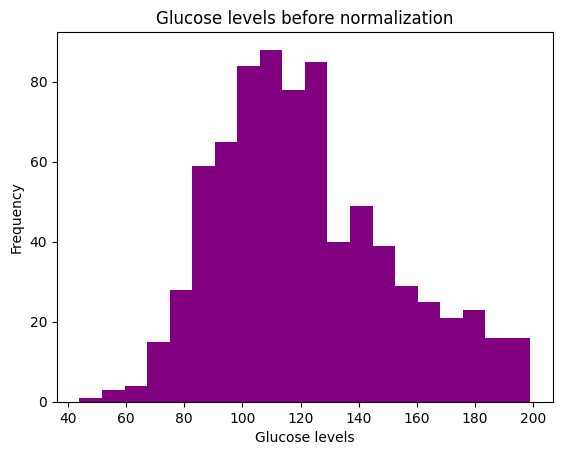

In [33]:
# Histogram of glucose levels before normalization
plt.hist(df['Glucose'], bins = 20, color = 'purple')
plt.title('Glucose levels before normalization')
plt.xlabel('Glucose levels')
plt.ylabel('Frequency')
plt.grid(False)

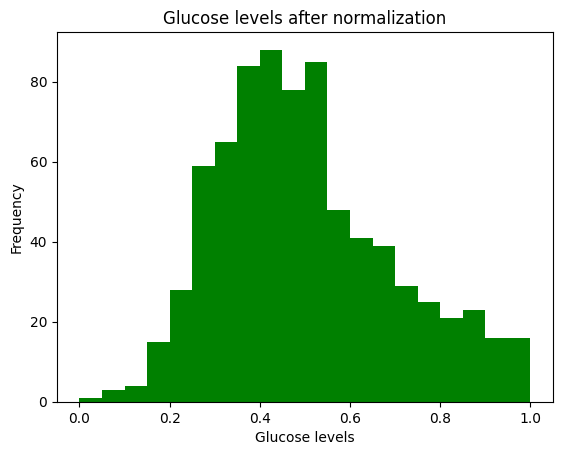

In [34]:
# Histogram of glucose levels after normalization
plt.hist(df_normal['Glucose'], bins = 20, color = 'green')
plt.title('Glucose levels after normalization')
plt.xlabel('Glucose levels')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

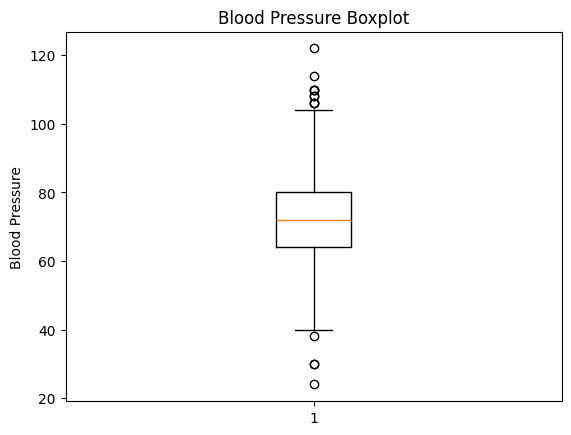

In [35]:
# Boxplot to identify outliers in blood pressure
plt.boxplot(df['BloodPressure'])
plt.title('Blood Pressure Boxplot')
plt.ylabel('Blood Pressure')
plt.show()

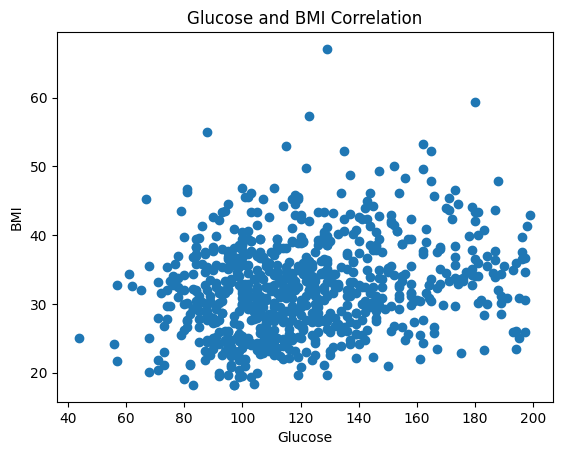

In [36]:
# Scatter plot between Glucose and BMI to analyze correlation
plt.scatter(df['Glucose'], df['BMI'])
plt.title('Glucose and BMI Correlation')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()

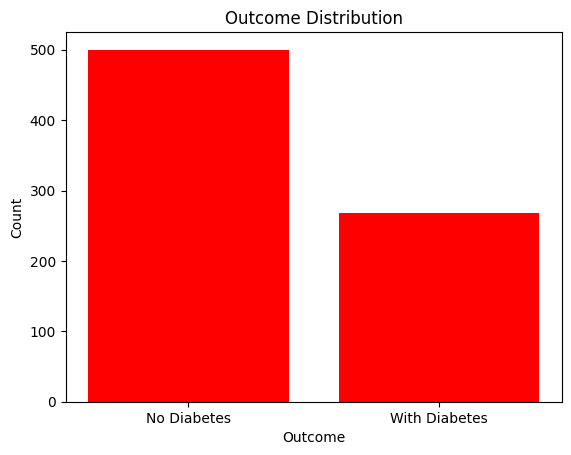

In [37]:
# Bar chart showing the number of patients with and without diabetes
outcome_values = df['Outcome'].value_counts()

plt.bar(['No Diabetes', 'With Diabetes'], outcome_values, color = 'red')
plt.title('Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

##  **Part 4: Answer the following questions (in a text cell!):**

### **1. What impact do missing values have on data analysis?**

The prescence of missing or inconsistent values can significantly distort the phase in which we carry out our statistical analyses. Sice these values introduce bias, alter the mean and standard deviation, and can lead to incorrect conclusions about the population. Furthermore, most Machine Learning algorithms cannot handle missing data or NaN (Not a Number) values directly, resulting in execution errors or severely degraded predictive performance if they are not properly handled during preprocessing.

### **2. How can we detect and handle outliers in biomedical datasets?**  



To detect and handle outliers in a biomedical dataset, we would firstly need to visually identify anomalies using boxplots, which display data distribution and highlight points that fall beyond the whiskers, or through scatter plots that reveal isolated values.



Also depending on the clinical context, the outliers can be handled by clamping/winsorizing (a previously established maximum acceptable threshold), imputation ( replacing them with the median or mean if they represent a measurement error), or by removal, this if we have a justification that the data point is related to a malfunction.  



### **3. What are some common causes of missing or incorrect data in biomedical studies?**

The most common causes, and primary responsables for incorrect or missing data are the equipment limitations or hardware malfunction, where sensors can become uncalibrated, lose power, or temporarily detach from a patient during continuous monitoring, leading to corrupted or missing readings. Human error also plays a significant role, particularly through the incorrect manual transcription of clinical metrics or patient charts into electronic health records. Furthermore, physiological constraints can corrupt data; since, biological samples may be insufficient or degrade during collection, making it complicated to obtain a valid laboratory reading, which often results in incorrect clinical parameters.

### **4. How does normalizing data improve the performance of Machine Learning models?**

Normalizing data is essential because clinical features usually exist on completely different scales. If the data is not normalized, machine learning models will inherently bias their predictions toward the variables with larger numbers, mistakenly assuming they are more important. By applying Min-Max Scaling to restrict all numerical features to a uniform range, we ensure that every clinical attribute contributes equally to the model's decisions. Additionally, this uniform scale helps optimization algorithms run much faster and smoother, resulting in stable training and higher overall predictive accuracy.

### **5. Why is visualizing data an important step before applying Machine Learning models?**

It serves as an essential diagnostic and exploratory tool that allows developers to understand the core characteristics of a dataset before fed into any Machine Learning algorithm. By generating plots such as histograms, boxplots, and scatter plots, we can visually assess the underlying statistical distribution of clinical variables, check for skewness, and confirm if features follow a normal distribution. We can also uncover patterns, such as linear or non-linear correlations between key attributes that can guide feature selection. Furthermore, it exposes critical data quality issues at a glance, such as extreme outliers that could distort training or severe class imbalances in the target label where one outcome heavily outweighs the other. *In general,  visualizing the data ensures that preprocessing techniques have been applied correctly and provides the empirical insights necessary to select the most appropriate model architecture.*

### **6. Why is preprocessing critical when working with medical datasets?**

In general is an absolute requirement when dealing with medical datasets because real-world clinical data is inherently noisy, incomplete, inconsistent, and highly heterogeneous. In a medical context, predictive models are directly tied to healthcare decision-making, demanding the highest possible standards of safety, robustness, and reliability. Training a Machine Learning model on raw, uncleaned medical data containing biological contradictions will inevitably lead to degraded performance and biased predictions. This can result in dangerous clinical outcomes, such as a high rate of false negatives where a patient's disease goes undetected, or false positives that trigger unnecessary and stressful interventions. Proper preprocessing can helps us safeguard the integrity of the data, minimize algorithmic bias, and ensure that the resulting model is clinically safe, interpretable, and capable of generalizing accurately to new patients.

### **7. What ethical concerns should be considered when handling patient data?**
The primary ethical concern is privacy and confidentiality, which requires strict data anonymization or de-identification techniques to ensure that a patient's identity cannot be reverse-engineered or exposed, strictly complying with international regulations. Another critical pillar is informed consent; researchers and developers must guarantee that patients are fully aware of how their clinical metrics are being utilized and have explicitly agreed to their use in technological or research developments.

## **Conclusion**
El desarrollo de esta práctica demostró que los conjuntos de datos reales suelen presentar inconsistencias que requieren un análisis crítico antes de cualquier procesamiento. En este caso, la presencia de valores en cero en variables biológicas clave, como la glucosa o la presión arterial, evidenció la necesidad de aplicar una etapa de curación de datos. Al sustituir estos errores por la mediana y normalizar los rangos mediante el método Min-Max, logramos estandarizar la información entre 0 y 1, asegurando que las distribuciones conservaran su comportamiento original pero en una escala uniforme.

El preprocesamiento y la limpieza son el núcleo de la ciencia de datos. Sin un tratamiento adecuado que considere el contexto del dominio médico, cualquier análisis o modelo predictivo posterior carecería de validez y confiabilidad estructural.

## **References:**
Matthes, E. (2023). Python Crash Course. No Starch Press.

W3Schools Python Guide